<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula08a_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
print("Keys of Iris dataset:", iris.keys())
print("Shape of data:", iris.data.shape)
print("Target names:", iris.target_names)

Keys of Iris dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Shape of data: (150, 4)
Target names: ['setosa' 'versicolor' 'virginica']


In [ ]:
import matplotlib.pyplot as plt

def plot_features_by_class(data, target, feature_names, feature_idx1, feature_idx2):
    """
    Plots two features from a dataset, coloring points by their class.

    Args:
        data (np.ndarray): The feature data (e.g., iris.data).
        target (np.ndarray): The target labels (e.g., iris.target).
        feature_names (list): A list of feature names (e.g., iris.feature_names).
        feature_idx1 (int): The index of the first feature to plot.
        feature_idx2 (int): The index of the second feature to plot.
    """
    unique_classes = set(target)

    for class_label in unique_classes:
        # Select data points belonging to the current class
        class_mask = (target == class_label)
        plt.scatter(
            data[class_mask, feature_idx1],
            data[class_mask, feature_idx2],
            label=iris.target_names[class_label], # Assuming target_names is available globally or passed
            alpha=0.3
        )

    plt.xlabel(feature_names[feature_idx1])
    plt.ylabel(feature_names[feature_idx2])
    plt.title(f'Scatter plot of {feature_names[feature_idx1]} vs {feature_names[feature_idx2]} by class')
    plt.legend()
    plt.grid(True)


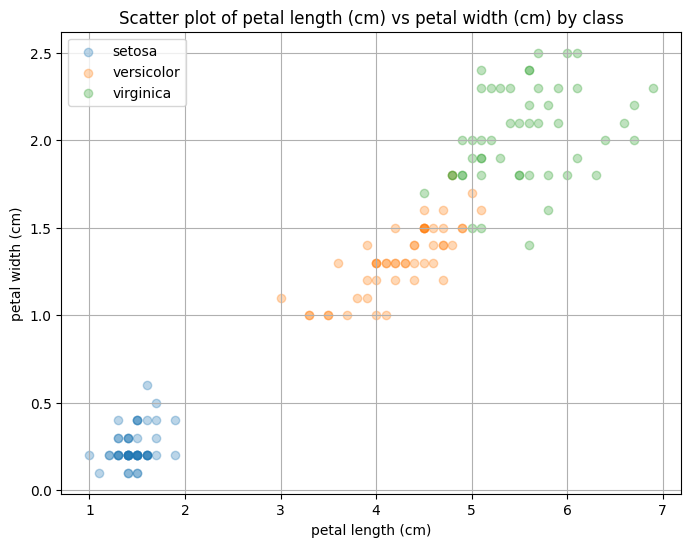

In [ ]:
plt.figure(figsize=(8, 6))
_ = plot_features_by_class(iris.data, iris.target, iris.feature_names, 2, 3)

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
import numpy as np

def euclidean_distance(x1, x2):
  return np.sqrt(np.sum((x1 - x2)**2))

class OneNN(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.X_ = X
    self.y_ = y
    return self
  def predict(self, X):
    y_pred = []
    for x in X:
      distances = []
      for i in range(len(self.X_)):
        distances.append(euclidean_distance(x, self.X_[i]))
      y_pred.append(self.y_[np.argmin(distances)])
    return np.array(y_pred)

model = OneNN()
model.fit(iris.data, iris.target)
y_pred = model.predict(iris.data)
acc = accuracy_score(iris.target, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [ ]:
def define_axes(X):
    offset = 0.5
    min1, max1 = X[:, 0].min(), X[:, 0].max()
    min2, max2 = X[:, 1].min(), X[:, 1].max()
    return [min1-offset, max1+offset, min2-offset, max2+offset]

def plot_predictions(clf, X):
    axes = define_axes(X)
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

Accuracy: 0.9866666666666667


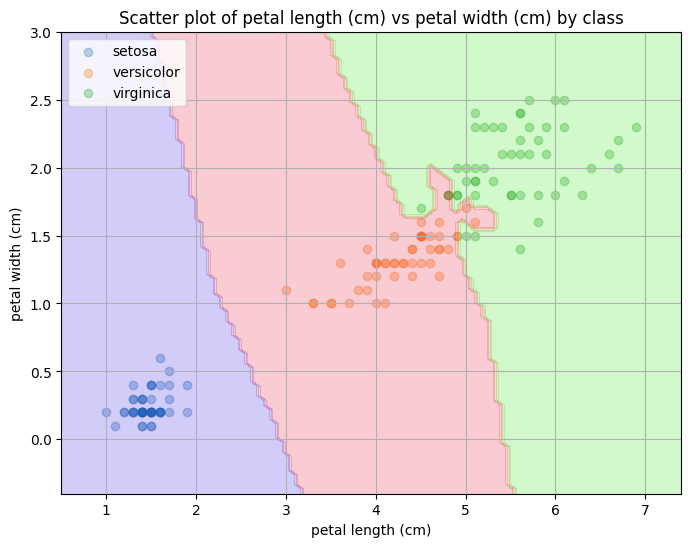

In [ ]:
model = OneNN()
def experiment(model):
  model.fit(iris.data[:,2:4], iris.target)
  y_pred = model.predict(iris.data[:,2:4])
  acc = accuracy_score(iris.target, y_pred)
  print("Accuracy:", acc)
  plt.figure(figsize=(8, 6))
  plot_features_by_class(iris.data, iris.target, iris.feature_names, 2, 3)
  plot_predictions(model, iris.data[:,2:4])
  plt.show()

experiment(model)

Accuracy: 0.9866666666666667


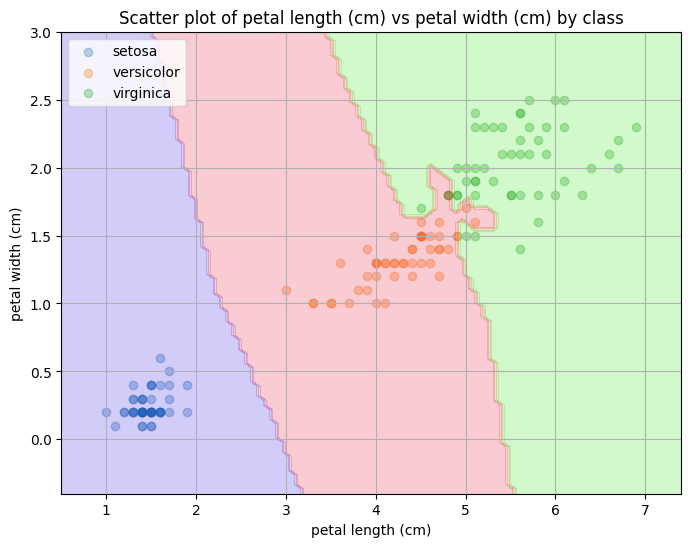

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)
experiment(model)

Accuracy: 0.98


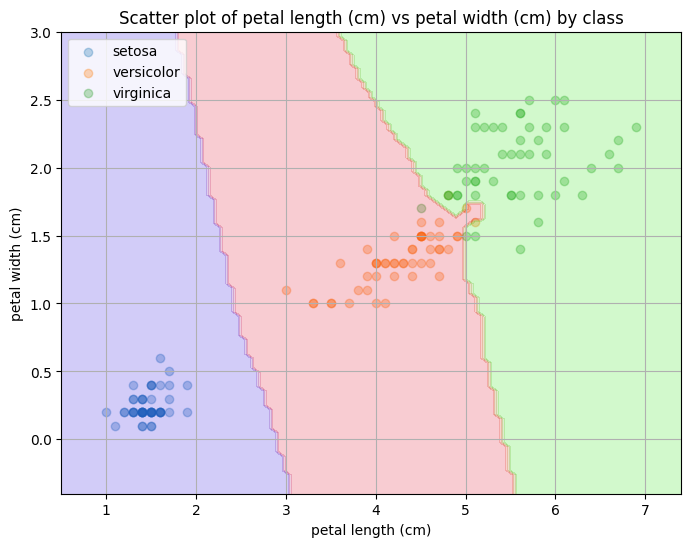

In [ ]:
experiment(KNeighborsClassifier(n_neighbors=3))

Accuracy: 0.96


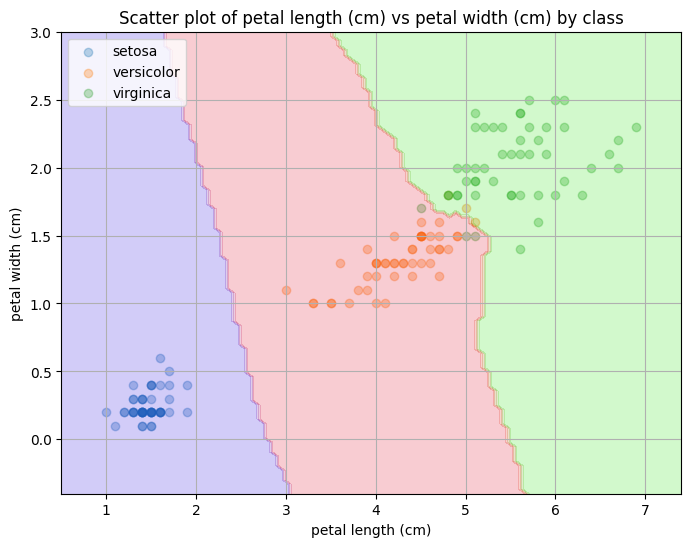

In [ ]:
experiment(KNeighborsClassifier(n_neighbors=5))

Accuracy: 0.9


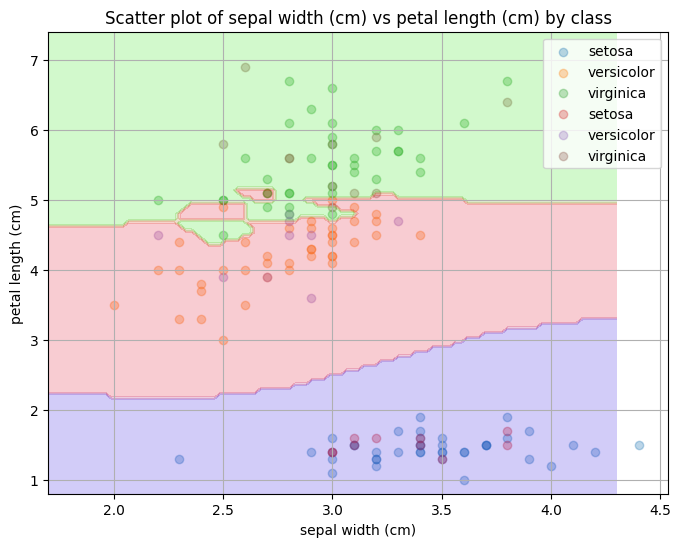

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris.data[:,1:3],
                                                    iris.target,
                                                    test_size=0.2,
                                                    random_state=42)
def experiment2(model):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  print("Accuracy:", acc)
  plt.figure(figsize=(8, 6))
  plot_features_by_class(X_train, y_train, iris.feature_names[1:3], 0, 1)
  plot_features_by_class(X_test, y_test, iris.feature_names[1:3], 0, 1)
  plot_predictions(model, X_test)
  plt.show()

experiment2(KNeighborsClassifier(n_neighbors=1))

Accuracy: 0.9333333333333333


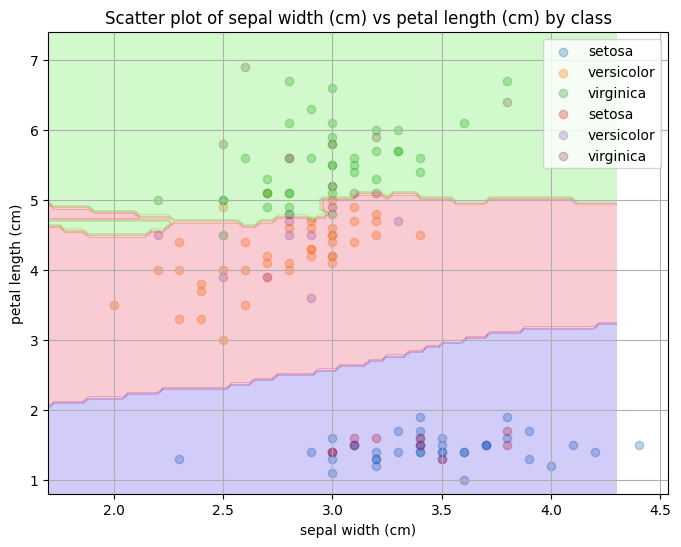

In [ ]:
experiment2(KNeighborsClassifier(n_neighbors=3))

Accuracy: 0.9666666666666667


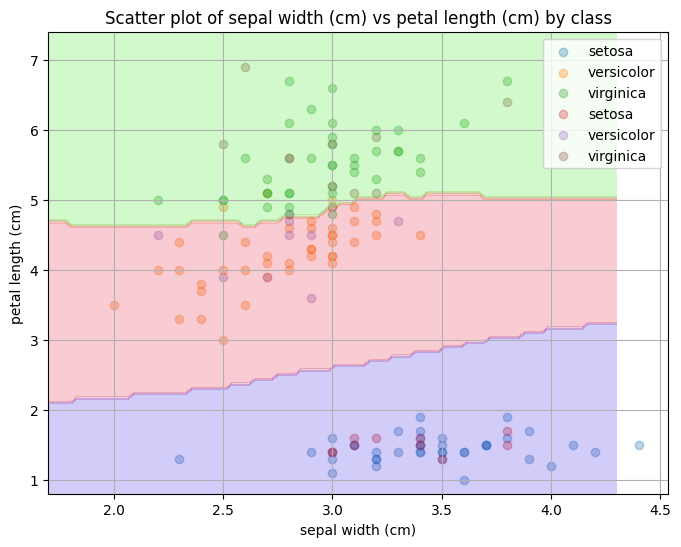

In [ ]:
experiment2(KNeighborsClassifier(n_neighbors=5))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(iris.data,
                                                    iris.target,
                                                    test_size=0.2)

def experiment3(model):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  print("Accuracy:", acc)

experiment3(KNeighborsClassifier(n_neighbors=1))
experiment3(KNeighborsClassifier(n_neighbors=3))
experiment3(KNeighborsClassifier(n_neighbors=5))

Accuracy: 0.9666666666666667
Accuracy: 0.9666666666666667
Accuracy: 1.0


In [ ]:
from sklearn.model_selection import cross_validate
from pprint import pprint

def experiment4(model):
  scores = cross_validate(model, iris.data, iris.target, cv=5)
  pprint(scores)
  print("Accuracy:", scores['test_score'].mean())

experiment4(KNeighborsClassifier(n_neighbors=1))
experiment4(KNeighborsClassifier(n_neighbors=3))
experiment4(KNeighborsClassifier(n_neighbors=5))

{'fit_time': array([0.00161052, 0.00140619, 0.00159431, 0.0013566 , 0.00133634]),
 'score_time': array([0.00354028, 0.00388694, 0.00327587, 0.00316381, 0.00332141]),
 'test_score': array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])}
Accuracy: 0.96
{'fit_time': array([0.00135803, 0.00239348, 0.00151491, 0.00138259, 0.00131774]),
 'score_time': array([0.00313306, 0.00325966, 0.00718212, 0.00329161, 0.00306821]),
 'test_score': array([0.96666667, 0.96666667, 0.93333333, 0.96666667, 1.        ])}
Accuracy: 0.9666666666666668
{'fit_time': array([0.0011754 , 0.00128531, 0.00128126, 0.00129795, 0.00132751]),
 'score_time': array([0.00268698, 0.00294995, 0.00300622, 0.0030117 , 0.00323892]),
 'test_score': array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])}
Accuracy: 0.9733333333333334


In [ ]:
from sklearn.model_selection import KFold

def experiment5(model):
  scores = cross_validate(model, iris.data, iris.target, cv=KFold(5, shuffle=True))
  pprint(scores)
  print("Accuracy:", scores['test_score'].mean())

experiment5(KNeighborsClassifier(n_neighbors=1))
experiment5(KNeighborsClassifier(n_neighbors=3))
experiment5(KNeighborsClassifier(n_neighbors=5))

{'fit_time': array([0.00135612, 0.00130868, 0.00117588, 0.00114632, 0.00111341]),
 'score_time': array([0.00414371, 0.00296879, 0.00297499, 0.00262523, 0.00273108]),
 'test_score': array([0.96666667, 0.93333333, 1.        , 0.93333333, 0.93333333])}
Accuracy: 0.9533333333333334
{'fit_time': array([0.00257993, 0.00131512, 0.00134158, 0.00127506, 0.00124502]),
 'score_time': array([0.00340939, 0.00319576, 0.00304627, 0.00303984, 0.00318575]),
 'test_score': array([1.        , 0.96666667, 0.93333333, 0.96666667, 0.93333333])}
Accuracy: 0.9600000000000002
{'fit_time': array([0.0013938 , 0.00127459, 0.00117278, 0.00092602, 0.00108886]),
 'score_time': array([0.00317216, 0.00329113, 0.00221586, 0.00276685, 0.00261617]),
 'test_score': array([1.        , 0.96666667, 1.        , 0.96666667, 0.93333333])}
Accuracy: 0.9733333333333334
